In [1]:
import os
import pandas as pd

In [2]:
df = pd.read_csv('./train.csv')
# Print basic information about the dataset
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*50)

# Display first few rows
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)

# Display basic info about the dataframe
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)

# Display statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50)

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# Display column names and data types
print("Columns and Data Types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Dataset Shape:
Rows: 59904, Columns: 88

First 5 rows:
   Unnamed: 0                                    id  sex  age  innet_dura  \
0           1  738f9d93-b51b-47c9-97f0-590527042013    1   34          17   
1           2  b0384a6e-0330-4e8f-a13e-b59acfcca5ad    1   37         132   
2           3  90631d89-e5f0-46eb-afd3-ac104f830fa1    1   41          35   
3           4  6dc8992e-5f5f-4f4b-90e6-cd1b00038928    1   34          91   
4           5  3ecaed5b-abd4-4a7e-9620-ee8441adc124    2   27         129   

    arpu  l3m_avg_mou  l3m_avg_dou  l3m_avg_bill_dura  cm_tot_bill_dura  ...  \
0   84.5    1049.0000     412.5410                0.0                 0  ...   
1  172.0     210.6667   25779.4310                0.0                 0  ...   
2  116.0      83.6667   14559.4574                0.0                 0  ...   
3  158.0     128.0000   34731.8750                0.0                 0  ...   
4   99.0      44.0000   29129.3919                0.0                 0  ...   

 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns found: {len(numeric_columns)}")
print("Numeric columns:", numeric_columns[:10], "...")  # Show first 10

# Calculate correlation matrix for numeric columns only
correlation_matrix = df[numeric_columns].corr()

# Get correlations with the target label
label_correlations = correlation_matrix['label'].sort_values(ascending=False)
print("\nCorrelation with Label (sorted):")
print(label_correlations)

Numeric columns found: 87
Numeric columns: ['Unnamed: 0', 'sex', 'age', 'innet_dura', 'arpu', 'l3m_avg_mou', 'l3m_avg_dou', 'l3m_avg_bill_dura', 'cm_tot_bill_dura', 'cm_local_voice_dura'] ...

Correlation with Label (sorted):
label                    1.000000
arpu                     0.348964
is_bd_tv                 0.148115
gprs_days                0.127634
l3m_avg_mou              0.094834
                           ...   
innet_dura              -0.036654
read_usr_lbl            -0.038246
is_bd_status_abnormal   -0.078128
fashion_time_m                NaN
hi_flux_usr_lbl               NaN
Name: label, Length: 87, dtype: float64


In [4]:
# 1. Basic correlation analysis with numeric data only
def analyze_correlations(df):
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Calculate correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Get correlations with label
    label_corr = corr_matrix['label'].drop('label').sort_values(key=abs, ascending=False)
    
    return corr_matrix, label_corr, numeric_cols

# Run the analysis
corr_matrix, label_correlations, numeric_cols = analyze_correlations(df)

print("Top 15 features most correlated with label:")
print(label_correlations.head(15))
print("\nTop 15 features least correlated with label:")
print(label_correlations.tail(15))

Top 15 features most correlated with label:
arpu                     0.348964
is_bd_tv                 0.148115
gprs_days                0.127634
l3m_avg_mou              0.094834
term_cont_mon            0.087319
cm_local_voice_dura      0.087294
is_bd_status_abnormal   -0.078128
term_cont_dfee           0.074877
open_day_m               0.072893
is_10g_pon               0.072071
watch_times_m            0.062024
login_times_m            0.060022
click_day_m              0.053700
user_duration_m          0.048385
cm_base_plan_flux_use    0.043815
Name: label, dtype: float64

Top 15 features least correlated with label:
travel_cnt_m             0.003607
read_time_m             -0.003090
edu_cnt_m                0.003053
if_like_games_cust       0.002350
anchor_dayt_use_dur     -0.001622
travel_time_m            0.001531
cm_chos_plan_flux_use   -0.001008
is_ent_vnet_user         0.000772
bd_cnt_m                 0.000724
edu_time_m              -0.000628
anchor_use_dur          -0.00045

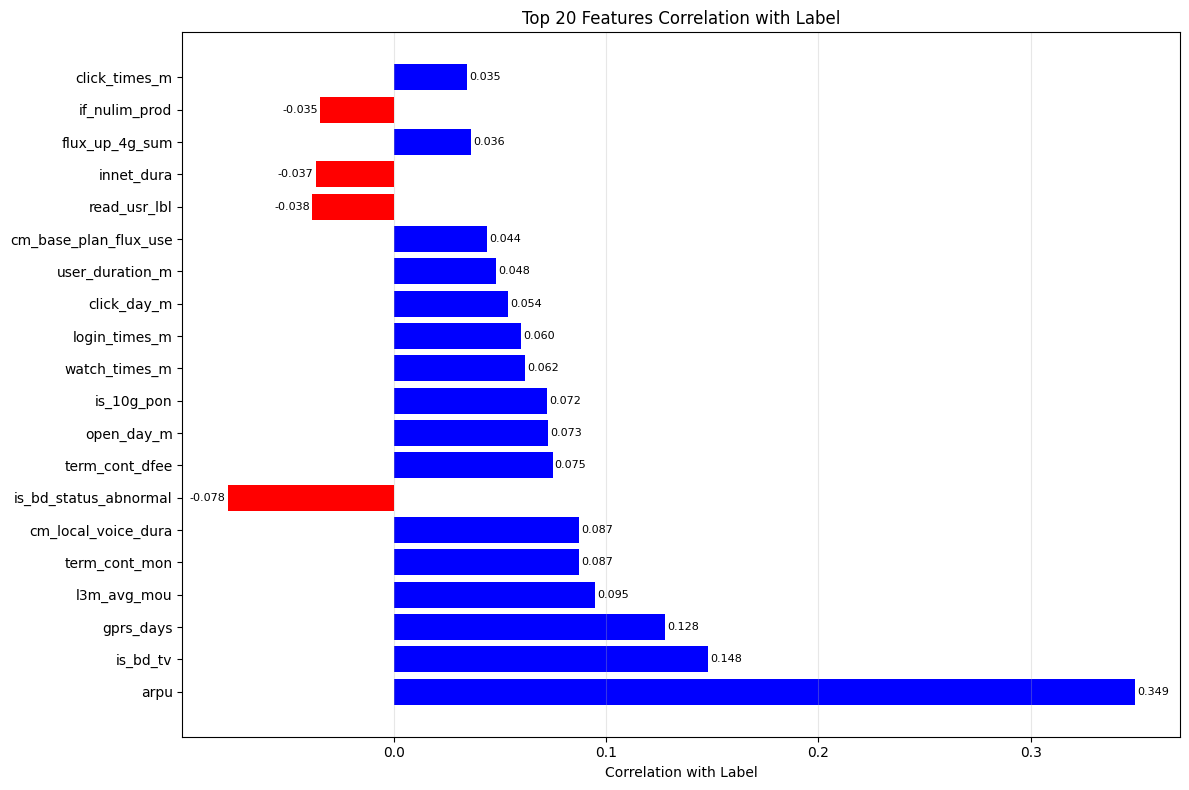

Missing values summary:
long_vid_ngt_use_dur     47451
gm_use_dur               47451
long_vid_dayt_use_dur    47451
long_vid_use_dur         47451
shrt_vid_ngt_use_dur     47451
shrt_vid_dayt_use_dur    47451
shrt_vid_use_dur         47451
sev_vid_usr_lbl          47451
liv_usr_lbl              47451
netdisk_usr_lbl          47451
vid_usr_lbl              47451
read_usr_lbl             47451
netdisk_dayt_use_dur     47451
netdisk_ngt_use_dur      47451
hi_flux_usr_lbl          47451
msc_usr_lbl              47451
gm_usr_lbl               47451
anchor_dayt_use_dur      47451
netdisk_use_dur          47451
wtch_liv_ngt_use_dur     47451
wtch_liv_dayt_use_dur    47451
wtch_liv_use_dur         47451
anchor_ngt_use_dur       47451
gm_ngt_use_dur           47451
gm_dayt_use_dur          47451
anchor_use_dur           47451
dtype: int64

Total samples: 59904
Complete cases: 12453

Top correlations using pairwise complete observations:
arpu                     0.348964
is_bd_tv               

In [5]:
# 2. Visualize top correlations with label
plt.figure(figsize=(12, 8))
top_corr = label_correlations.head(20)
colors = ['red' if x < 0 else 'blue' for x in top_corr.values]
bars = plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), top_corr.index, fontsize=10)
plt.xlabel('Correlation with Label')
plt.title('Top 20 Features Correlation with Label')
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_corr.values)):
    plt.text(val + 0.001 if val >= 0 else val - 0.001, i, f'{val:.3f}', 
             va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# 3. Handle missing values and recalculate correlations
print("Missing values summary:")
missing_summary = df[numeric_cols].isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

# Option 1: Use pairwise correlations (handles missing values automatically)
print(f"\nTotal samples: {len(df)}")
print(f"Complete cases: {len(df.dropna())}")

# Calculate pairwise correlations (default behavior)
pairwise_corr = df[numeric_cols].corr()['label'].drop('label').sort_values(key=abs, ascending=False)
print("\nTop correlations using pairwise complete observations:")
print(pairwise_corr.head(15))

In [6]:
# Calculate missing percentages
missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({
    'column': missing_stats.index,
    'missing_count': missing_stats.values,
    'missing_percent': missing_percent.values
}).sort_values('missing_percent', ascending=False)

print("Missing data summary:")
print(missing_df[missing_df['missing_percent'] > 0])

Missing data summary:
                   column  missing_count  missing_percent
70         anchor_use_dur          47451        79.211739
69   long_vid_ngt_use_dur          47451        79.211739
61             gm_use_dur          47451        79.211739
68  long_vid_dayt_use_dur          47451        79.211739
67       long_vid_use_dur          47451        79.211739
66   shrt_vid_ngt_use_dur          47451        79.211739
65  shrt_vid_dayt_use_dur          47451        79.211739
64       shrt_vid_use_dur          47451        79.211739
80        sev_vid_usr_lbl          47451        79.211739
81            liv_usr_lbl          47451        79.211739
82        netdisk_usr_lbl          47451        79.211739
83            vid_usr_lbl          47451        79.211739
84           read_usr_lbl          47451        79.211739
77   netdisk_dayt_use_dur          47451        79.211739
78    netdisk_ngt_use_dur          47451        79.211739
79        hi_flux_usr_lbl          47451        79

In [7]:
# Group 1: High missing rate features (79% missing)
high_missing_cols = missing_df[missing_df['missing_percent'] > 70]['column'].tolist()
print(f"High missing columns ({len(high_missing_cols)}): {high_missing_cols}")

# Group 2: Complete features (0% missing)
complete_cols = missing_df[missing_df['missing_percent'] == 0]['column'].tolist()
print(f"Complete columns ({len(complete_cols)}): {len(complete_cols)} features")

# Strategy options:
# Option 1: Drop high missing features
df_cleaned = df.drop(columns=high_missing_cols)

# Option 2: Keep and impute (if you believe they're important)
# For usage duration features, 0 might be meaningful (no usage)
df_imputed = df.copy()
for col in high_missing_cols:
    if 'use_dur' in col or 'usr_lbl' in col:
        df_imputed[col] = df_imputed[col].fillna(0)  # Assume no usage

High missing columns (26): ['anchor_use_dur', 'long_vid_ngt_use_dur', 'gm_use_dur', 'long_vid_dayt_use_dur', 'long_vid_use_dur', 'shrt_vid_ngt_use_dur', 'shrt_vid_dayt_use_dur', 'shrt_vid_use_dur', 'sev_vid_usr_lbl', 'liv_usr_lbl', 'netdisk_usr_lbl', 'vid_usr_lbl', 'read_usr_lbl', 'netdisk_dayt_use_dur', 'netdisk_ngt_use_dur', 'hi_flux_usr_lbl', 'msc_usr_lbl', 'gm_usr_lbl', 'anchor_dayt_use_dur', 'netdisk_use_dur', 'wtch_liv_ngt_use_dur', 'wtch_liv_dayt_use_dur', 'wtch_liv_use_dur', 'anchor_ngt_use_dur', 'gm_ngt_use_dur', 'gm_dayt_use_dur']
Complete columns (62): 62 features


Top 15 correlations with statistical info:
                  feature  correlation        p_value  sample_size  \
4                    arpu     0.348964   0.000000e+00        59904   
32               is_bd_tv     0.148115  6.370375e-291        59904   
24              gprs_days     0.127634  5.812284e-216        59904   
5             l3m_avg_mou     0.094834  1.054375e-119        59904   
39          term_cont_mon     0.087319  1.031823e-101        59904   
9     cm_local_voice_dura     0.087294  1.177303e-101        59904   
27  is_bd_status_abnormal    -0.078128   9.501095e-82        59904   
40         term_cont_dfee     0.074877   3.193742e-75        59904   
37             open_day_m     0.072893   2.243082e-71        59904   
28             is_10g_pon     0.072071   8.182242e-70        59904   
36          watch_times_m     0.062024   3.822132e-52        59904   
34          login_times_m     0.060022   6.122605e-49        59904   
38            click_day_m     0.053700   1.6479

/tmp/ipykernel_2206777/713501959.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(valid_data[col], valid_data[target_col])
/tmp/ipykernel_2206777/713501959.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(valid_data[col], valid_data[target_col])


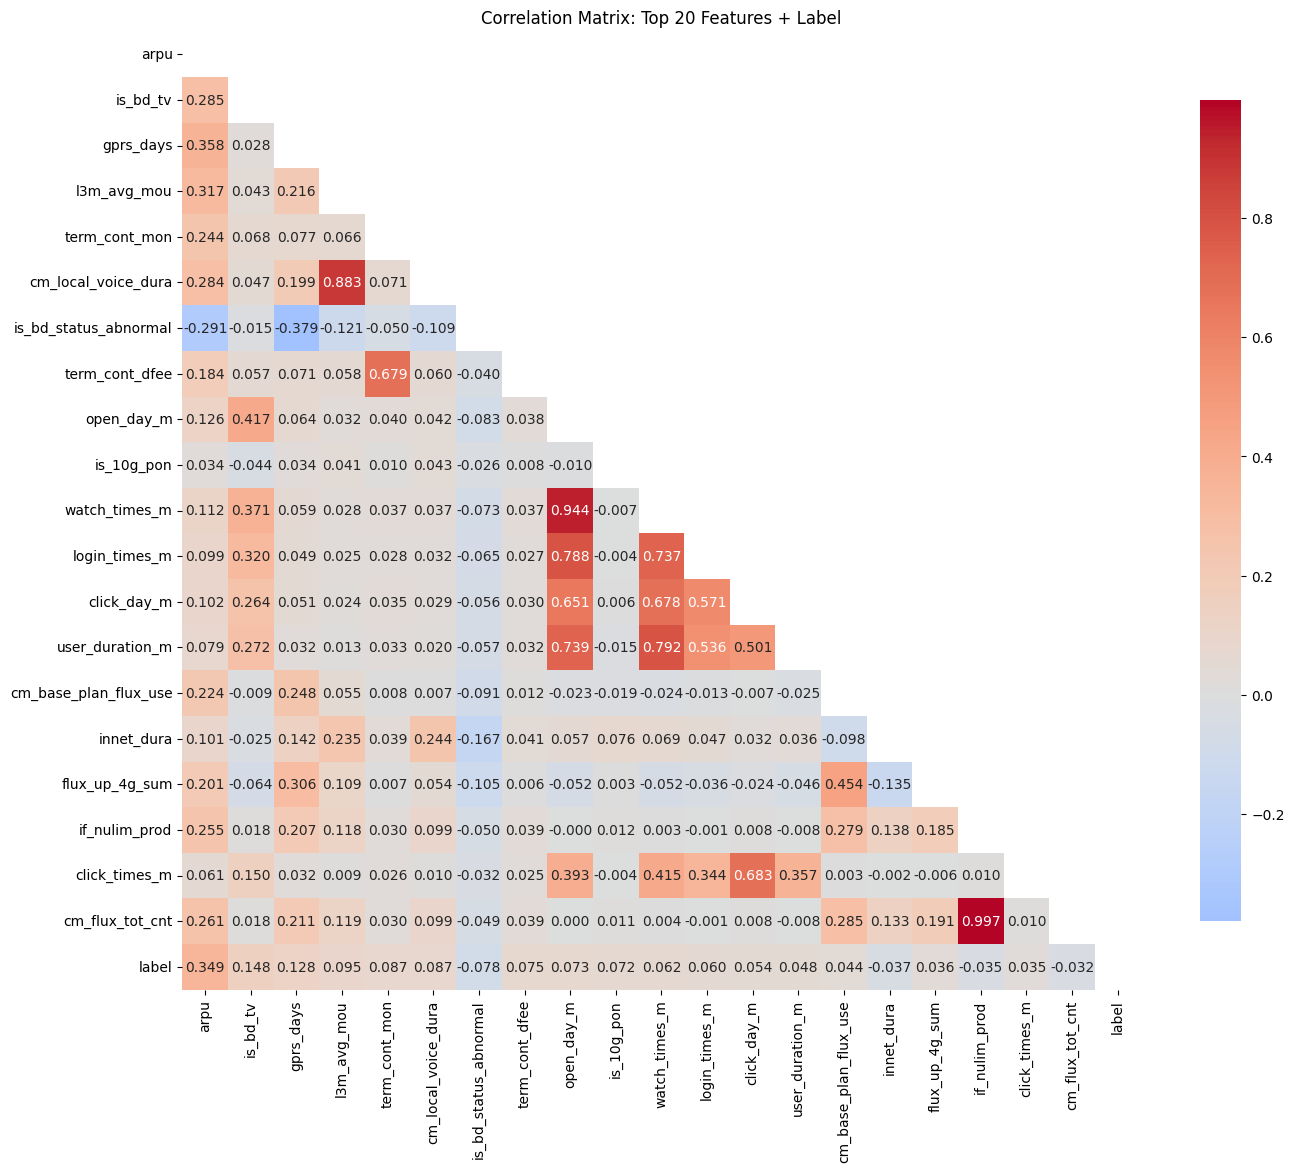

In [8]:
# 4. Statistical significance testing
from scipy.stats import pearsonr

def correlation_with_significance(df, target_col='label'):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    correlations = []
    
    for col in numeric_cols:
        if col != target_col:
            # Get valid pairs (non-missing)
            valid_data = df[[col, target_col]].dropna()
            
            if len(valid_data) > 10:  # Minimum sample size
                try:
                    corr, p_value = pearsonr(valid_data[col], valid_data[target_col])
                    correlations.append({
                        'feature': col,
                        'correlation': corr,
                        'p_value': p_value,
                        'abs_correlation': abs(corr),
                        'sample_size': len(valid_data),
                        'missing_pct': (len(df) - len(valid_data)) / len(df) * 100
                    })
                except:
                    continue
    
    # Convert to DataFrame and sort
    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('abs_correlation', ascending=False)
    
    return corr_df

# Get correlations with significance
corr_results = correlation_with_significance(df_imputed)
print("Top 15 correlations with statistical info:")
print(corr_results.head(15)[['feature', 'correlation', 'p_value', 'sample_size', 'missing_pct']])

# Filter for significant correlations
significant_corr = corr_results[corr_results['p_value'] < 0.05]
print(f"\nStatistically significant correlations (p < 0.05): {len(significant_corr)}")
print("\nTop 10 significant correlations:")
print(significant_corr.head(10)[['feature', 'correlation', 'p_value']])

# 5. Visualize correlation heatmap for top features
top_features = corr_results.head(20)['feature'].tolist() + ['label']
subset_corr = df_imputed[top_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(subset_corr, dtype=bool))  # Mask upper triangle
sns.heatmap(subset_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix: Top 20 Features + Label')
plt.tight_layout()
plt.show()

Top 15 features by Random Forest importance:
                feature  importance
4                  arpu    0.126466
3            innet_dura    0.040907
19    cm_base_plan_flux    0.038693
18      cm_flux_tot_cnt    0.036466
29            bd_flux_m    0.033269
0            Unnamed: 0    0.032478
5           l3m_avg_mou    0.031142
2                   age    0.030543
9   cm_local_voice_dura    0.030228
12       flux_up_4g_sum    0.030193
30             bd_dur_m    0.029677
6           l3m_avg_dou    0.029243
11          flux_4g_use    0.029182
13     flux_down_4g_sum    0.029081
16       nwday_day_flux    0.028218


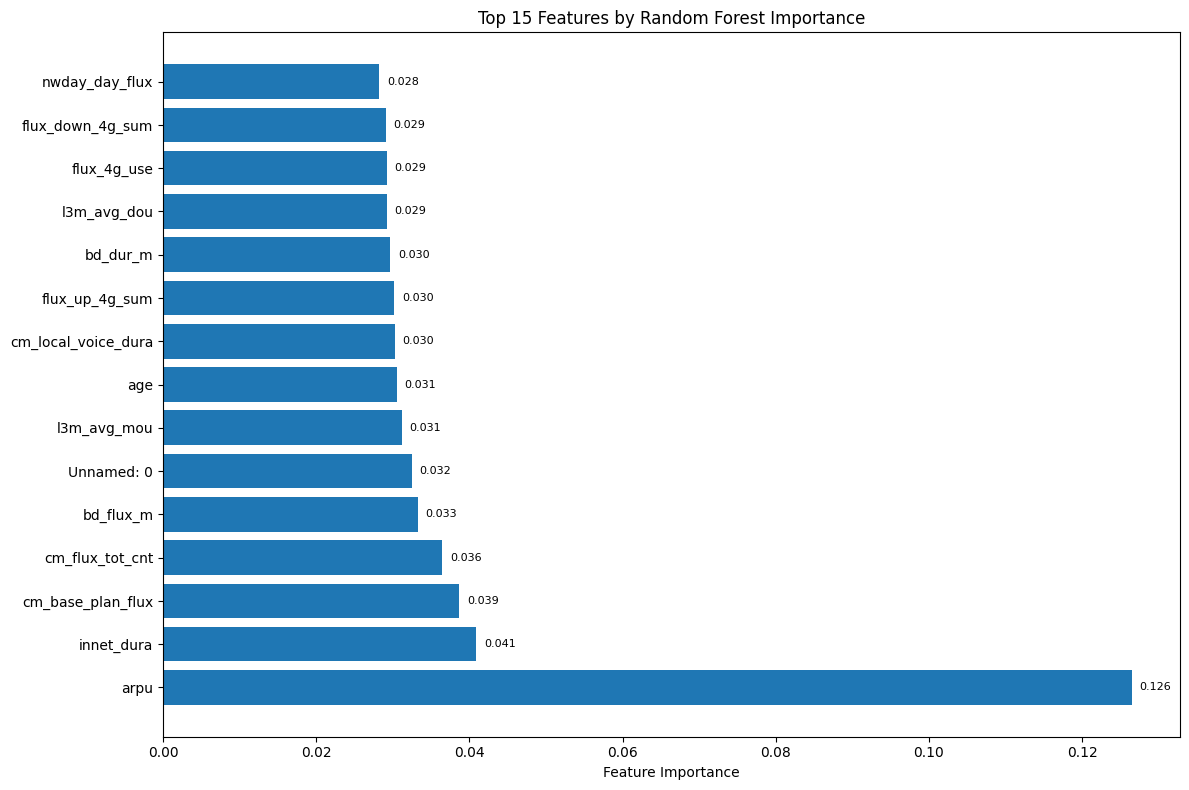


Model Accuracy: 0.802

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88      8981
           1       0.69      0.38      0.49      3000

    accuracy                           0.80     11981
   macro avg       0.75      0.66      0.68     11981
weighted avg       0.79      0.80      0.78     11981



In [9]:
# 6. Analyze missing data patterns
def analyze_missing_patterns(df):
    missing_cols = df.columns[df.isnull().any()].tolist()
    
    if len(missing_cols) > 0:
        print("Missing data analysis:")
        print(f"Columns with missing data: {len(missing_cols)}")
        
        # Check if missing data is related to label
        for col in missing_cols[:10]:  # Check first 10 missing columns
            missing_mask = df[col].isnull()
            if missing_mask.sum() > 0:
                label_0_missing = missing_mask[df['label'] == 0].mean()
                label_1_missing = missing_mask[df['label'] == 1].mean()
                print(f"{col}: Label 0 missing: {label_0_missing:.1%}, Label 1 missing: {label_1_missing:.1%}")

analyze_missing_patterns(df_imputed)

# 7. Feature importance using Random Forest (handles missing values)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare data - fill missing values with median for numeric columns
X = df_imputed[numeric_cols].copy()
X = X.drop('label', axis=1)  # Remove target
X_filled = X.fillna(X.median())  # Fill with median
y = df_imputed['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_filled.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features by Random Forest importance:")
print(importance_df.head(15))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_importance = importance_df.head(15)
bars = plt.barh(range(len(top_importance)), top_importance['importance'])
plt.yticks(range(len(top_importance)), top_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features by Random Forest Importance')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_importance['importance'])):
    plt.text(val + 0.001, i, f'{val:.3f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

# Model performance
from sklearn.metrics import classification_report, accuracy_score
y_pred = rf.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select top features based on importance and correlation
top_features_rf = [
    'arpu', 'innet_dura', 'cm_base_plan_flux', 'cm_flux_tot_cnt', 
    'bd_flux_m', 'l3m_avg_mou', 'age', 'flux_up_4g_sum', 
    'l3m_avg_dou', 'cm_local_voice_dura', 'bd_dur_m', 
    'flux_down_4g_sum', 'wday_day_flux', 'flux_4g_use', 'cm_flux_use'
]

# Add some additional features with good correlation
additional_features = [
    'gprs_days', 'is_bd_tv', 'term_cont_mon', 'is_bd_status_abnormal',
    'user_duration_m', 'login_times_m', 'click_times_m', 'watch_times_m'
]

# Combine features
selected_features = top_features_rf + additional_features
print(f"Selected {len(selected_features)} features for neural network")

# Prepare the dataset
def prepare_data(df, features, target='label'):
    # Select features and target
    X = df[features].copy()
    y = df[target].copy()
    
    # Handle missing values - use median for robustness
    X_filled = X.fillna(X.median())
    
    # Check for any remaining missing values
    print(f"Missing values after filling: {X_filled.isnull().sum().sum()}")
    
    return X_filled, y

X, y = prepare_data(df_imputed, selected_features)
print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {y.value_counts()}")

Selected 23 features for neural network
Missing values after filling: 0
Dataset shape: (59904, 23)
Class distribution: label
0    44904
1    15000
Name: count, dtype: int64


In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (classification_report, roc_auc_score, precision_score, 
                           recall_score, f1_score, confusion_matrix, average_precision_score)
import matplotlib.pyplot as plt
from collections import Counter

from scipy.spatial.distance import cdist

class FastCustomSMOTE:
    """Ultra-fast SMOTE using scipy for distance computation"""
    def __init__(self, k_neighbors=5, random_state=42):
        self.k_neighbors = k_neighbors
        self.random_state = random_state
        np.random.seed(random_state)
    
    def fit_resample(self, X, y):
        X = np.array(X)
        y = np.array(y)
        
        unique_classes, class_counts = np.unique(y, return_counts=True)
        majority_class_count = np.max(class_counts)
        
        X_resampled = [X]
        y_resampled = [y]
        
        for class_label in unique_classes:
            class_count = np.sum(y == class_label)
            
            if class_count < majority_class_count:
                class_samples = X[y == class_label]
                samples_needed = majority_class_count - class_count
                
                k_actual = min(self.k_neighbors, len(class_samples) - 1)
                
                if k_actual > 0:
                    # Ultra-fast distance computation with scipy
                    distances = cdist(class_samples, class_samples, metric='euclidean')
                    
                    # Get k+1 nearest neighbors (excluding self)
                    neighbor_indices = np.argpartition(distances, k_actual+1, axis=1)[:, 1:k_actual+1]
                    
                    # Random sample selection
                    sample_indices = np.random.randint(0, len(class_samples), size=samples_needed)
                    selected_neighbors = neighbor_indices[sample_indices]
                    neighbor_idx = selected_neighbors[
                        np.arange(samples_needed), 
                        np.random.randint(0, k_actual, size=samples_needed)
                    ]
                    
                    # Vectorized synthetic sample generation
                    gaps = np.random.random(size=(samples_needed, 1))
                    synthetic_samples = (class_samples[sample_indices] + 
                                       gaps * (class_samples[neighbor_idx] - class_samples[sample_indices]))
                    
                    synthetic_labels = np.full(samples_needed, class_label)
                    
                    X_resampled.append(synthetic_samples)
                    y_resampled.append(synthetic_labels)
        
        return np.vstack(X_resampled), np.hstack(y_resampled)


class HybridCustomTomekLinks:
    """Hybrid approach balancing speed and memory"""
    def __init__(self, use_scipy=True, chunk_size=5000):
        self.use_scipy = use_scipy
        self.chunk_size = chunk_size
    
    def fit_resample(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples = len(X)
        
        # Choose method based on dataset size
        if n_samples < self.chunk_size:
            # Small dataset: use fast vectorized approach
            if self.use_scipy:
                from scipy.spatial.distance import cdist
                distances = cdist(X, X, metric='euclidean')
            else:
                diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
                distances = np.sqrt(np.sum(diff ** 2, axis=2))
            
            np.fill_diagonal(distances, np.inf)
            nearest_indices = np.argmin(distances, axis=1)
        else:
            # Large dataset: use chunked approach
            nearest_indices = self._find_nearest_chunked(X)
        
        # Vectorized Tomek link detection
        is_mutual = nearest_indices[nearest_indices] == np.arange(n_samples)
        different_classes = y != y[nearest_indices]
        is_tomek = is_mutual & different_classes
        
        keep_indices = ~is_tomek
        
        return X[keep_indices], y[keep_indices]
    
    def _find_nearest_chunked(self, X):
        """Chunked processing for large datasets"""
        n_samples = len(X)
        nearest_indices = np.zeros(n_samples, dtype=np.int64)
        
        for start in range(0, n_samples, self.chunk_size):
            end = min(start + self.chunk_size, n_samples)
            chunk = X[start:end]
            
            if self.use_scipy:
                from scipy.spatial.distance import cdist
                distances = cdist(chunk, X, metric='euclidean')
            else:
                diff = chunk[:, np.newaxis, :] - X[np.newaxis, :, :]
                distances = np.sqrt(np.sum(diff ** 2, axis=2))
            
            # Set self-distances to infinity
            for i in range(end - start):
                distances[i, start + i] = np.inf
            
            nearest_indices[start:end] = np.argmin(distances, axis=1)
        
        return nearest_indices

class ChurnPredictionNN(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rate=0.3):
        super(ChurnPredictionNN, self).__init__()
        
        # Input layer
        layers = []
        prev_size = input_size
        
        # Hidden layers with batch normalization and dropout
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        return self.network(x)


class ChurnPredictor:
    def __init__(self, model, device='cpu', use_smote=True, use_tomek=True):
        self.model = model.to(device)
        self.device = device
        self.scaler = RobustScaler()
        self.use_smote = use_smote
        self.use_tomek = use_tomek
        self.smote = FastCustomSMOTE(k_neighbors=5,
                            # sampling_strategy=0.6,  # 60% ratio
                            # borderline=True,        # Focus on boundary
                            random_state=42
                        )
        self.tomek = HybridCustomTomekLinks()
        self.history = {
            'train_loss': [], 'val_loss': [], 
            'train_f1': [], 'val_f1': [],
            'train_recall': [], 'val_recall': [],
            'learning_rate': []
        }
        self.best_threshold = 0.5
    
    def prepare_data(self, X, y, test_size=0.2, val_size=0.2):
        """Enhanced data preparation with stratification"""
        # **IMPROVEMENT 2: Stratified split with more validation data for threshold tuning**
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 25% for better threshold tuning
        )
        
        print(f"Original training distribution: {Counter(y_train)}")
        print(f"Class ratio: {y_train.sum() / len(y_train):.3f}")
        
        # Apply resampling
        if self.use_smote or self.use_tomek:
            X_train_array = X_train.values if hasattr(X_train, 'values') else X_train
            y_train_array = y_train.values if hasattr(y_train, 'values') else y_train
            
            if self.use_smote:
                print("Applying SMOTE with 0.85 ratio...")
                X_train_array, y_train_array = self.smote.fit_resample(X_train_array, y_train_array)
                print(f"After SMOTE: {Counter(y_train_array)}")
                print(f"New ratio: {y_train_array.sum() / len(y_train_array):.3f}")
            
            if self.use_tomek:
                print("Cleaning with Tomek Links...")
                X_train_array, y_train_array = self.tomek.fit_resample(X_train_array, y_train_array)
                print(f"After cleaning: {Counter(y_train_array)}")
            
            X_train = pd.DataFrame(X_train_array, columns=X_train.columns if hasattr(X_train, 'columns') else range(X_train_array.shape[1]))
            y_train = pd.Series(y_train_array)
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled).to(self.device)
        y_train_tensor = torch.FloatTensor(y_train.values).to(self.device)
        X_val_tensor = torch.FloatTensor(X_val_scaled).to(self.device)
        y_val_tensor = torch.FloatTensor(y_val.values).to(self.device)
        X_test_tensor = torch.FloatTensor(X_test_scaled).to(self.device)
        y_test_tensor = torch.FloatTensor(y_test.values).to(self.device)
        
        return (X_train_tensor, y_train_tensor), (X_val_tensor, y_val_tensor), (X_test_tensor, y_test_tensor)
    
    def focal_loss(self, inputs, targets, alpha=0.25, gamma=2.0):
        """Enhanced focal loss with numerical stability"""
        # Use BCEWithLogitsLoss for numerical stability
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        
        # Calculate probabilities
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        
        # **IMPROVEMENT 3: Add epsilon for numerical stability**
        pt = torch.clamp(pt, min=1e-8, max=1.0)
        
        # Modulating factor
        focal_weight = (1 - pt) ** gamma
        
        # Alpha balancing - give more weight to minority class
        alpha_t = torch.where(targets == 1, alpha, 1 - alpha)
        
        focal_loss = alpha_t * focal_weight * BCE_loss
        
        return focal_loss.mean()
    
    def combined_loss(self, inputs, targets, pos_weight, alpha=0.25, gamma=2.0, focal_weight=0.7):
        """
        **IMPROVEMENT 4: Hybrid loss combining focal loss and weighted BCE**
        This helps balance hard example mining with class imbalance handling
        """
        # Focal loss component
        focal = self.focal_loss(inputs, targets, alpha, gamma)
        
        # Weighted BCE component
        bce = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, pos_weight=pos_weight
        )
        
        # Combine both losses
        return focal_weight * focal + (1 - focal_weight) * bce
    
    def train(self, train_data, val_data, epochs=150, batch_size=256, lr=0.001,
              weight_decay=1e-4, use_hybrid_loss=True, 
              patience=40, min_delta=0.0001):
        """Enhanced training with better monitoring and early stopping"""
        X_train, y_train = train_data
        X_val, y_val = val_data
        
        # **IMPROVEMENT 5: Calculate class weights even after SMOTE**
        pos_count = (y_train == 1).sum().item()
        neg_count = (y_train == 0).sum().item()
        pos_weight = torch.tensor([neg_count / pos_count]).to(self.device)
        
        print(f"Training set - Positive: {pos_count}, Negative: {neg_count}")
        print(f"Pos weight for loss: {pos_weight.item():.3f}")
        
        # **IMPROVEMENT 6: Use hybrid loss by default**
        if use_hybrid_loss:
            criterion = lambda inputs, targets: self.combined_loss(
                inputs, targets, pos_weight,
                alpha=0.75,      # High alpha for minority class
                gamma=2.5,       # Moderate gamma
                focal_weight=0.6 # Balance between focal and BCE
            )
            print("Using Hybrid Loss (Focal + Weighted BCE)")
        else:
            criterion = lambda inputs, targets: self.focal_loss(
                inputs, targets, alpha=0.75, gamma=2.5
            )
            print("Using Pure Focal Loss")
        
        # **IMPROVEMENT 7: Better optimizer configuration**
        optimizer = optim.AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
            betas=(0.9, 0.999),
            eps=1e-8
        )
        
        # **IMPROVEMENT 8: OneCycleLR for better convergence**
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=lr * 10,
            epochs=epochs,
            steps_per_epoch=len(X_train) // batch_size + 1,
            pct_start=0.3,
            anneal_strategy='cos'
        )
        
        # Create data loader
        train_dataset = TensorDataset(X_train, y_train)
        train_loader = DataLoader(
            train_dataset, 
            batch_size=batch_size, 
            shuffle=True,
            drop_last=True  # Avoid batch norm issues with small last batch
        )
        
        best_val_f1 = 0.0
        best_epoch = 0
        patience_counter = 0
        
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            train_loss = 0
            train_predictions = []
            train_targets = []
            train_probs = []
            
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = self.model(batch_X).squeeze()
                
                # Ensure correct dimensions
                if outputs.dim() == 0:
                    outputs = outputs.unsqueeze(0)
                if batch_y.dim() == 0:
                    batch_y = batch_y.unsqueeze(0)
                
                loss = criterion(outputs, batch_y)
                
                # **IMPROVEMENT 9: Gradient anomaly detection**
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"⚠️  NaN/Inf loss at epoch {epoch}, skipping batch")
                    continue
                
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                
                optimizer.step()
                scheduler.step()
                
                train_loss += loss.item()
                
                # Track predictions
                probs = torch.sigmoid(outputs)
                predicted = (probs > 0.5).float()
                
                train_predictions.extend(predicted.cpu().numpy())
                train_targets.extend(batch_y.cpu().numpy())
                train_probs.extend(probs.detach().cpu().numpy())
            
            # **IMPROVEMENT 10: Comprehensive validation with threshold search**
            self.model.eval()
            with torch.no_grad():
                val_outputs = self.model(X_val).squeeze()
                val_probs = torch.sigmoid(val_outputs).cpu().numpy()
                y_val_np = y_val.cpu().numpy()
                
                # Calculate validation loss
                val_loss = criterion(val_outputs, y_val).item()
                
                # **Find best threshold on validation set every N epochs**
                if epoch % 5 == 0 or epoch < 10:
                    best_threshold, best_f1 = self._find_best_threshold(
                        val_probs, y_val_np
                    )
                    self.best_threshold = best_threshold
                else:
                    val_predicted = (val_probs > self.best_threshold).astype(int)
                    best_f1 = f1_score(y_val_np, val_predicted, zero_division=0)
                
                val_predicted = (val_probs > self.best_threshold).astype(int)
                val_recall = recall_score(y_val_np, val_predicted, zero_division=0)
                val_precision = precision_score(y_val_np, val_predicted, zero_division=0)
                
                # Training metrics with best threshold
                train_probs_np = np.array(train_probs)
                train_targets_np = np.array(train_targets)
                train_predicted = (train_probs_np > self.best_threshold).astype(int)
                train_f1 = f1_score(train_targets_np, train_predicted, zero_division=0)
                train_recall = recall_score(train_targets_np, train_predicted, zero_division=0)
            
            # Record metrics
            avg_train_loss = train_loss / len(train_loader)
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(best_f1)
            self.history['train_recall'].append(train_recall)
            self.history['val_recall'].append(val_recall)
            self.history['learning_rate'].append(optimizer.param_groups[0]['lr'])
            
            # **IMPROVEMENT 11: Smarter early stopping based on F1**
            if best_f1 > best_val_f1 + min_delta:
                best_val_f1 = best_f1
                best_epoch = epoch
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_threshold': self.best_threshold,
                    'best_f1': best_f1,
                }, 'best_churn_model.pth')
            else:
                patience_counter += 1
            
            # Logging
            if epoch % 10 == 0 or epoch < 5:
                print(f'\n{"="*70}')
                print(f'Epoch {epoch}/{epochs}:')
                print(f'  LR: {optimizer.param_groups[0]["lr"]:.6f}')
                print(f'  Train - Loss: {avg_train_loss:.4f}, F1: {train_f1:.4f}, Recall: {train_recall:.4f}')
                print(f'  Val   - Loss: {val_loss:.4f}, F1: {best_f1:.4f}, Recall: {val_recall:.4f}')
                print(f'  Val Precision: {val_precision:.4f}')
                print(f'  Best Threshold: {self.best_threshold:.3f}')
                print(f'  Val Predictions: {np.bincount(val_predicted)}')
                print(f'  Patience: {patience_counter}/{patience}')
            
            # Early stopping
            if patience_counter >= patience:
                print(f'\n⏹️  Early stopping at epoch {epoch}')
                print(f'   Best F1: {best_val_f1:.4f} at epoch {best_epoch}')
                break
        
        # Load best model
        checkpoint = torch.load('best_churn_model.pth', weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.best_threshold = checkpoint['best_threshold']
        print(f'\n✅ Loaded best model from epoch {checkpoint["epoch"]}')
        print(f'   Best F1: {checkpoint["best_f1"]:.4f}')
        print(f'   Best Threshold: {self.best_threshold:.3f}')
    
    def _find_best_threshold(self, probabilities, true_labels, metric='f1'):
        """
        **IMPROVEMENT 12: Sophisticated threshold optimization**
        Find optimal threshold based on specified metric
        """
        thresholds = np.arange(0.1, 0.9, 0.02)
        best_score = 0
        best_threshold = 0.5
        
        for threshold in thresholds:
            predictions = (probabilities > threshold).astype(int)
            
            if metric == 'f1':
                score = f1_score(true_labels, predictions, zero_division=0)
            elif metric == 'recall':
                score = recall_score(true_labels, predictions, zero_division=0)
            elif metric == 'balanced':
                # Balance between precision and recall
                prec = precision_score(true_labels, predictions, zero_division=0)
                rec = recall_score(true_labels, predictions, zero_division=0)
                score = 2 * (prec * rec) / (prec + rec + 1e-8)
            
            if score > best_score:
                best_score = score
                best_threshold = threshold
        
        return best_threshold, best_score
    
    def evaluate(self, test_data, threshold=None):
        """Enhanced evaluation with multiple metrics"""
        if threshold is None:
            threshold = self.best_threshold
        
        X_test, y_test = test_data
        self.model.eval()
        
        with torch.no_grad():
            test_outputs = self.model(X_test).squeeze()
            test_probabilities = torch.sigmoid(test_outputs).cpu().numpy()
            y_test_np = y_test.cpu().numpy()
            
            # Predictions with threshold
            test_predicted = (test_probabilities > threshold).astype(int)
            
            # **IMPROVEMENT 13: Comprehensive metrics**
            accuracy = accuracy_score(y_test_np, test_predicted)
            precision = precision_score(y_test_np, test_predicted, zero_division=0)
            recall = recall_score(y_test_np, test_predicted, zero_division=0)
            f1 = f1_score(y_test_np, test_predicted, zero_division=0)
            auc_score = roc_auc_score(y_test_np, test_probabilities)
            avg_precision = average_precision_score(y_test_np, test_probabilities)
            
            # Balanced accuracy (important for imbalanced data)
            balanced_acc = balanced_accuracy_score(y_test_np, test_predicted)
            
            # Matthews Correlation Coefficient (good for imbalanced data)
            mcc = matthews_corrcoef(y_test_np, test_predicted)
            
            print(f"\n{'='*70}")
            print(f"📊 Test Results (threshold={threshold:.3f}):")
            print(f"{'='*70}")
            print(f"Accuracy:          {accuracy:.4f}")
            print(f"Balanced Accuracy: {balanced_acc:.4f}")
            print(f"Precision:         {precision:.4f}")
            print(f"Recall:            {recall:.4f}")
            print(f"F1 Score:          {f1:.4f}")
            print(f"MCC:               {mcc:.4f}")
            print(f"AUC-ROC:           {auc_score:.4f}")
            print(f"Avg Precision:     {avg_precision:.4f}")
            
            cm = confusion_matrix(y_test_np, test_predicted)
            print(f"\n📈 Confusion Matrix:")
            print(f"                Predicted")
            print(f"                0      1")
            print(f"Actual 0    {cm[0,0]:5d}  {cm[0,1]:5d}")
            print(f"Actual 1    {cm[1,0]:5d}  {cm[1,1]:5d}")
            
            # Calculate cost-sensitive metrics
            tn, fp, fn, tp = cm.ravel()
            print(f"\n💡 Detailed Breakdown:")
            print(f"True Negatives:  {tn:5d}")
            print(f"False Positives: {fp:5d}")
            print(f"False Negatives: {fn:5d}")
            print(f"True Positives:  {tp:5d}")
            print(f"Specificity:     {tn/(tn+fp):.4f}")
            print(f"NPV:             {tn/(tn+fn):.4f}" if (tn+fn) > 0 else "NPV: N/A")
            
            print(f"\n{classification_report(y_test_np, test_predicted, target_names=['Not Churn', 'Churn'])}")
            
            return {
                'accuracy': accuracy,
                'balanced_accuracy': balanced_acc,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'mcc': mcc,
                'auc': auc_score,
                'avg_precision': avg_precision,
                'predictions': test_predicted,
                'probabilities': test_probabilities,
                'true_labels': y_test_np,
                'confusion_matrix': cm,
                'threshold': threshold
            }
    
    def plot_training_history(self):
        """Enhanced visualization"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Loss
        axes[0, 0].plot(self.history['train_loss'], label='Train Loss', alpha=0.8, linewidth=2)
        axes[0, 0].plot(self.history['val_loss'], label='Val Loss', alpha=0.8, linewidth=2)
        axes[0, 0].set_title('Loss Over Time', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # F1 Score
        axes[0, 1].plot(self.history['train_f1'], label='Train F1', alpha=0.8, linewidth=2)
        axes[0, 1].plot(self.history['val_f1'], label='Val F1', alpha=0.8, linewidth=2)
        axes[0, 1].set_title('F1 Score Over Time', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('F1 Score')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Recall
        axes[1, 0].plot(self.history['train_recall'], label='Train Recall', alpha=0.8, linewidth=2)
        axes[1, 0].plot(self.history['val_recall'], label='Val Recall', alpha=0.8, linewidth=2)
        axes[1, 0].set_title('Recall Over Time', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Recall')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Learning Rate
        axes[1, 1].plot(self.history['learning_rate'], alpha=0.8, linewidth=2, color='orange')
        axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [20]:
class AttentionChurnNN(nn.Module):
    """Neural network with attention mechanism for better feature selection"""
    
    def __init__(self, input_size, hidden_sizes=[256, 128, 64], 
                 dropout_rate=0.3, use_attention=True):
        super().__init__()
        
        self.use_attention = use_attention
        
        # Input batch norm
        self.input_bn = nn.BatchNorm1d(input_size)
        
        # Feature attention (learn which features are important)
        if use_attention:
            self.feature_attention = nn.Sequential(
                nn.Linear(input_size, input_size // 4),
                nn.ReLU(),
                nn.Linear(input_size // 4, input_size),
                nn.Sigmoid()
            )
        
        # Main network
        layers = []
        prev_size = input_size
        
        for i, hidden_size in enumerate(hidden_sizes):
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.SiLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        self.main_network = nn.Sequential(*layers)
        
        # Output layer
        self.output = nn.Linear(prev_size, 1)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_bn(x)
        
        # Apply attention to input features
        if self.use_attention:
            attention_weights = self.feature_attention(x)
            x = x * attention_weights
        
        x = self.main_network(x)
        x = self.output(x)
        
        return x

In [21]:
def mixup_data(x, y, alpha=0.2):
    """
    Mixup augmentation for better generalization
    Creates synthetic samples by mixing pairs
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Loss for mixup"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# In training loop:


In [ ]:
# Create model with attention
# # Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_size = len(selected_features)
model = AttentionChurnNN(
    input_size=input_size,
    hidden_sizes=[256, 128, 64],
    dropout_rate=0.3,
    use_attention=True
)

# Use calibrated predictor with improved SMOTE
predictor = ChurnPredictor(model, device, use_smote=False, use_tomek=False)

# Prepare data
train_data, val_data, test_data = predictor.prepare_data(X, y)

# Train with mixup and temperature scaling
predictor.train(
    train_data, 
    val_data, 
    epochs=200, 
    batch_size=256,
    # use_mixup=True,
    # mixup_alpha=0.2
)

# Calibration happens automatically after training

# Evaluate on test set
X_test, y_test = test_data
predictions, calibrated_probs = predictor.evaluate(X_test)

print("\n" + "="*60)
print("Final Test Results (with calibration)")
print("="*60)
print(f"Threshold: {predictor.best_threshold:.4f}")
print(f"Accuracy: {accuracy_score(y_test.cpu(), predictions):.4f}")
print(f"Precision: {precision_score(y_test.cpu(), predictions):.4f}")
print(f"Recall: {recall_score(y_test.cpu(), predictions):.4f}")
print(f"F1 Score: {f1_score(y_test.cpu(), predictions):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test.cpu(), calibrated_probs):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test.cpu(), predictions))
print("\nClassification Report:")
print(classification_report(y_test.cpu(), predictions))

Using device: cuda
Original training distribution: Counter({0: 26942, 1: 9000})
Class ratio: 0.250
Training set - Positive: 9000, Negative: 26942
Pos weight for loss: 2.994
Using Hybrid Loss (Focal + Weighted BCE)

Epoch 0/200:
  LR: 0.000406
  Train - Loss: 0.4275, F1: 0.4801, Recall: 0.6487
  Val   - Loss: 0.3704, F1: 0.5493, Recall: 0.6903
  Val Precision: 0.4562
  Best Threshold: 0.520
  Val Predictions: [7441 4540]
  Patience: 0/40

Epoch 1/200:
  LR: 0.000426
  Train - Loss: 0.3920, F1: 0.5108, Recall: 0.5736
  Val   - Loss: 0.3628, F1: 0.5567, Recall: 0.6443
  Val Precision: 0.4900
  Best Threshold: 0.580
  Val Predictions: [8036 3945]
  Patience: 0/40

Epoch 2/200:
  LR: 0.000458
  Train - Loss: 0.3814, F1: 0.5345, Recall: 0.7128
  Val   - Loss: 0.3602, F1: 0.5582, Recall: 0.7407
  Val Precision: 0.4479
  Best Threshold: 0.520
  Val Predictions: [7020 4961]
  Patience: 0/40

Epoch 3/200:
  LR: 0.000503
  Train - Loss: 0.3751, F1: 0.5395, Recall: 0.7562
  Val   - Loss: 0.3604, F

AttributeError: 'ChurnPredictor' object has no attribute 'predict'